<a href="https://colab.research.google.com/github/elbuh0/genai-course/blob/main/genai-course/week2/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Diffusion Models: UNet DDPM from Scratch
**COM SCI-X 455 · Week 2 · Megan Armani, PhD**

> Push to `genai-course/week2/`

---

## Setup

In [ ]:
!pip install diffusers accelerate torch torchvision matplotlib --quiet

In [ ]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


## Note on Homework Extension
The **lab** trains on MNIST. Your **homework** extends to FashionMNIST:
```python
# One-line swap:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
```
The UNet and training loop are identical. FashionMNIST is harder — observe how many epochs your model needs vs MNIST.

## Part 1 — Forward Process (Noise Schedule)
**Goal:** Implement the linear and cosine variance schedules and visualise what they do to an image.

In [ ]:
def linear_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T=1000, s=0.008):
    steps = torch.arange(T+1, dtype=torch.float32)
    f = torch.cos(((steps/T + s) / (1+s)) * torch.pi/2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0, 0.999)

In [ ]:
# TODO: Implement `q_sample(x0, t, betas)` — the closed-form forward process.
#Formula: x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps where eps ~ N(0,I) and alpha_bar_t = prod(1 - beta_i for i in 1..t) Hint: precompute alpha_bar from betas.

def q_sample(x0, t, betas):
    # Compute alpha_t = 1 - beta_t
    alphas = 1.0 - betas

    # Compute cumulative product:
    # alpha_bar_t = alpha_1 * alpha_2 * ... * alpha_t
    alpha_bars = torch.cumprod(alphas, dim=0)

    # Get alpha_bar for the requested timestep(s)
    alpha_bar_t = alpha_bars[t]

    # Reshape for broadcasting over image dimensions
    alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)

    # Sample Gaussian noise: epsilon ~ N(0, I)
    eps = torch.randn_like(x0)

    # Closed-form forward diffusion process
    x_t = (
        torch.sqrt(alpha_bar_t) * x0
        + torch.sqrt(1.0 - alpha_bar_t) * eps
    )

    return x_t, eps


100%|██████████| 9.91M/9.91M [00:00<00:00, 14.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 342kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


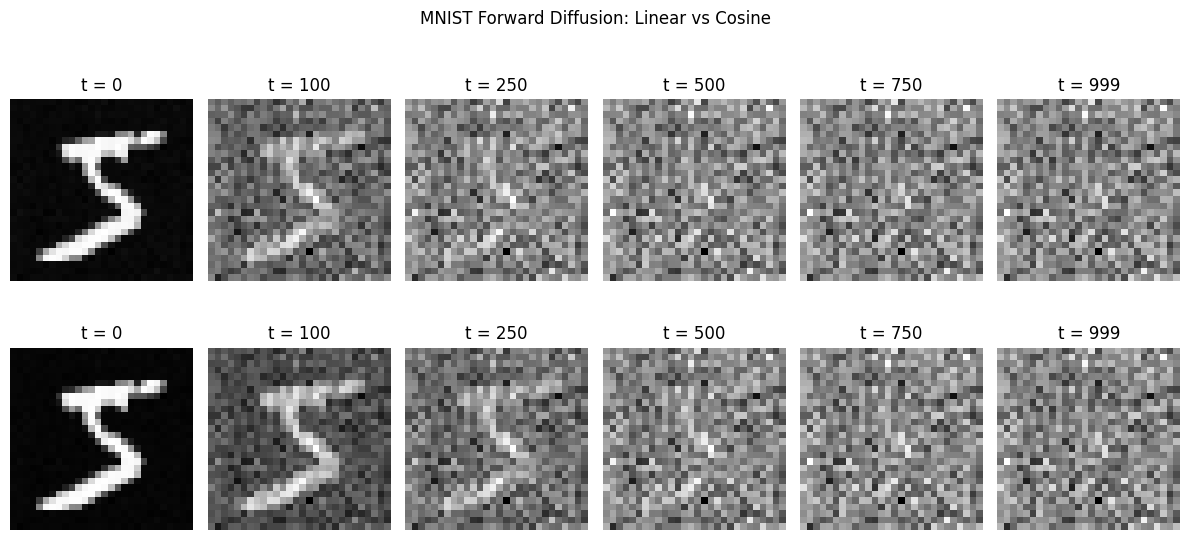

In [ ]:
# TODO: Visualise the noising process: take one MNIST image, show it at t=0, 250, 500, 750, 1000 for BOTH linear and cosine schedules side by side. Which schedule destroys fine detail faster?

from torch.serialization import T
import torch, torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class NoiseSchedule:
  def __init__(self, T=1000, schedule="linear", device="cuda"):
    self.T = T
    if schedule == "linear":
      betas = torch.linspace(1e-4, 0.02, T) # b1 ... b_T
    elif schedule == "cosine":
      # Improved DDPM (Nichol & Dhariwal 2021)
      s = 0.008
      steps = torch.arange(T+1, dtype=torch.float32) / T
      alphas_cumprod = torch.cos((steps + s) / (1+s) * torch.pi/2) ** 2
      alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
      betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
      betas = torch.clamp(betas, 0, 0.999)

    self.betas = betas.to(device)
    self.alphas = 1 - self.betas
    self.alphas_cumprod = torch.cumprod(self.alphas, 0).to(device)

  def q_sample(self, x0, t, noise=None):
    if noise is None:
      noise = torch.randn_like(x0)
    at = self.alphas_cumprod[t].view(-1, 1, 1, 1)
    return torch.sqrt(at) * x0 + torch.sqrt(1-at) * noise, noise


# Load one MNIST image
transform = transforms.ToTensor()
dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)

x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)

# Create linear and cosine schedules
linear = NoiseSchedule(T=1000, schedule="linear", device=DEVICE)
cosine = NoiseSchedule(T=1000, schedule="cosine", device=DEVICE)

# Timesteps to show
timesteps = [0, 100, 250, 500, 750, 999]

# Use the same noise for both schedules
noise = torch.randn_like(x0)

fig, axes = plt.subplots(2, 6, figsize=(12, 6))

# Linear schedule
for i, t in enumerate(timesteps):
    xt, _ = linear.q_sample(
        x0,
        torch.tensor([t], device=DEVICE),
        noise=noise
    )

    axes[0, i].imshow(xt[0, 0].detach().cpu(), cmap="gray")
    axes[0, i].set_title(f"t = {t}")
    axes[0, i].axis("off")

axes[0, 0].set_ylabel("Linear", fontsize=12)

# Cosine schedule
for i, t in enumerate(timesteps):
    xt, _ = cosine.q_sample(
        x0,
        torch.tensor([t], device=DEVICE),
        noise=noise
    )

    axes[1, i].imshow(xt[0, 0].detach().cpu(), cmap="gray")
    axes[1, i].set_title(f"t = {t}")
    axes[1, i].axis("off")

axes[1, 0].set_ylabel("Cosine", fontsize=12)

plt.suptitle("MNIST Forward Diffusion: Linear vs Cosine")
plt.tight_layout()
plt.show()


Cosine shows noticeably greater detail preserved at t = 100, 250 and 500, indicating cosine's subtler signal fade and only creeping noise increase at the outset. However, at 500 there is clear transition as core details vanish with signal and noise at least equal. By t = 1000, the image is almost entirely comprised of noise.

## Part 2 — U-Net Noise Predictor

In [ ]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half-1)))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
  def __init__(self, in_ch, out_ch, time_dim=128):
    super().__init__()
    self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
    self.time_proj = nn.Linear(time_dim, out_ch)

    self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
    self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)

  def forward(self, x, t_emb):
    h = F.silu(self.norm1(x))
    h = self.conv1(h) + self.time_proj(t_emb)[:, :, None, None]

    h = F.silu(self.norm2(h))
    h = self.conv2(h)

    return h + self.skip(x)

In [ ]:
# TODO: Build a UNet class with:
# - Encoder: 3 levels (32→64→128 channels), each with ResBlock + downsample
# - Bottleneck: ResBlock with time embedding
# - Decoder: 3 levels with skip connections + upsample
# - Time embedding fed to every ResBlock
# Input: (B, 1, 28, 28) noisy image + timestep t
# Output: (B, 1, 28, 28) predicted noise

class TimeEmbedding(nn.Module):
  def __init__(self, dim):
    super().__init__()
    self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.SiLU(), nn.Linear(dim*4, dim))

  def forward(self, t, dim=128):
      half = dim // 2
      freq = torch.exp(-torch.arange(half, device=t.device) * (8.0/half))
      args = t[:, None].float() * freq[None]
      embedding = torch.cat([torch.cos(args), torch.sin(args)], -1)
      return self.mlp(embedding)

class ResBlock(nn.Module):
  def __init__(self, in_ch, out_ch, time_dim=128):
    super().__init__()
    self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
    self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
    self.time_proj = nn.Linear(time_dim, out_ch) # adds time info as bias
    self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    self.norm1 = nn.GroupNorm(8, in_ch)
    self.norm2 = nn.GroupNorm(8, out_ch)

  def forward(self, x, t_emb):
    h = F.silu(self.norm1(x))
    h = self.conv1(h) + self.time_proj(t_emb)[:, :, None, None]

    h = F.silu(self.norm2(h))
    h = self.conv2(h)
    return h + self.skip(x) # residual connection

class SimpleUNet(nn.Module):
  def __init__(self, channels=[32,64,128], time_dim=128):
      super().__init__()
      self.time_embed = TimeEmbedding(time_dim)
      self.down = nn.ModuleList() # encoder
      self.up   = nn.ModuleList() # decoder
      in_ch = 1 # MNIST is grayscale

      for ch in channels:
        self.down.append(ResBlock(in_ch, ch, time_dim))
        in_ch = ch

      self.bottleneck = ResBlock(channels[-1], channels[-1], time_dim)

      in_ch = channels[-1]*2
      for ch in reversed(channels):
        self.up.append(ResBlock(in_ch + ch, ch, time_dim)) # +ch for skip
        in_ch = ch

      self.final = nn.Conv2d(channels[0], 1, 1) # predict noise

  def forward(self, x, t):
      t_emb = self.time_embed(t)
      skips = []

      for block in self.down:
          x = block(x, t_emb)
          skips.append(x)
          x = F.max_pool2d(x, 2)

      x = self.bottleneck(x, t_emb)

      for block, skip in zip(self.up, reversed(skips)):
        x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        x = block(torch.cat([x, skip], 1), t_emb) # paste skip connection

      return self.final(x) # predicted noise epsilon_theta


In [ ]:
#UNet class LLM build
class TimeEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half = 128 // 2
        freq = torch.exp(
            -torch.arange(half, device=t.device) * (8.0 / half)
        )
        args = t[:, None].float() * freq[None]
        embedding = torch.cat(
            [torch.cos(args), torch.sin(args)], dim=-1
        )
        return self.mlp(embedding)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=128):
        super().__init__()

        # Fix: Ensure num_groups is divisible by num_channels
        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        # Fix: Ensure num_groups is divisible by num_channels
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)

        # Add timestep information
        h = h + self.time_proj(t_emb)[:, :, None, None]

        h = F.silu(self.norm2(h))
        h = self.conv2(h)

        return h + self.skip(x)


class SimpleUNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()

        self.time_embed = TimeEmbedding(time_dim)

        # Encoder: 1 → 32 → 64 → 128
        self.down1 = ResBlock(1, 32, time_dim)
        self.down2 = ResBlock(32, 64, time_dim)
        self.down3 = ResBlock(64, 128, time_dim)

        # Bottleneck
        self.bottleneck = ResBlock(128, 128, time_dim)

        # Decoder
        self.up1 = ResBlock(128 + 128, 128, time_dim)
        self.up2 = ResBlock(128 + 64, 64, time_dim)
        self.up3 = ResBlock(64 + 32, 32, time_dim)

        # Predict one-channel noise
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encoder
        x1 = self.down1(x, t_emb)
        x2 = self.down2(F.max_pool2d(x1, 2), t_emb)
        x3 = self.down3(F.max_pool2d(x2, 2), t_emb)

        # Bottleneck
        x = self.bottleneck(F.max_pool2d(x3, 2), t_emb)

        # Decoder + skip connections
        x = F.interpolate(x, size=x3.shape[-2:], mode="nearest")
        x = self.up1(torch.cat([x, x3], dim=1), t_emb)

        x = F.interpolate(x, size=x2.shape[-2:], mode="nearest")
        x = self.up2(torch.cat([x, x2], dim=1), t_emb)

        x = F.interpolate(x, size=x1.shape[-2:], mode="nearest")
        x = self.up3(torch.cat([x, x1], dim=1), t_emb)

        return self.final(x)

## Part 3 — Training Loop

In [ ]:
# Training function

def train(model, schedule, loader, epochs=30, device=DEVICE,
          schedule_name="Linear", ckpt_epochs=(5, 10, 20, 30)):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    checkpoints = {}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, _ in loader:
            x0 = x0.to(device)

            # Sample random timestep t for each image in batch
            t = torch.randint(0, schedule.T, (x0.shape[0],), device=device)

            # Get noisy image and the actual noise added
            xt, noise = schedule.q_sample(x0, t)

            # Predict noise epsilon_theta(x_t, t)
            pred_noise = model(xt, t)

            # MSE between actual and predicted noise
            loss = F.mse_loss(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        losses.append(avg)

        print(f"Epoch {epoch:3d}/{epochs} | loss: {avg:.4f}")

        # Snapshot weights at the checkpoint epochs
        if epoch in ckpt_epochs:
            checkpoints[epoch] = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    # Plot training loss
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"UNet DDPM Training Loss - {schedule_name} Schedule")
    plt.grid(alpha=0.3)
    plt.show()

    return losses, checkpoints

Epoch  1/30 | Loss: 0.0539
Epoch  2/30 | Loss: 0.0241
Epoch  3/30 | Loss: 0.0214
Epoch  4/30 | Loss: 0.0197
Epoch  5/30 | Loss: 0.0188
Epoch  6/30 | Loss: 0.0184
Epoch  7/30 | Loss: 0.0178
Epoch  8/30 | Loss: 0.0175
Epoch  9/30 | Loss: 0.0171
Epoch 10/30 | Loss: 0.0168
Epoch 11/30 | Loss: 0.0166
Epoch 12/30 | Loss: 0.0165
Epoch 13/30 | Loss: 0.0164
Epoch 14/30 | Loss: 0.0162
Epoch 15/30 | Loss: 0.0162
Epoch 16/30 | Loss: 0.0159
Epoch 17/30 | Loss: 0.0158
Epoch 18/30 | Loss: 0.0158
Epoch 19/30 | Loss: 0.0159
Epoch 20/30 | Loss: 0.0157
Epoch 21/30 | Loss: 0.0153
Epoch 22/30 | Loss: 0.0155
Epoch 23/30 | Loss: 0.0156
Epoch 24/30 | Loss: 0.0153
Epoch 25/30 | Loss: 0.0153
Epoch 26/30 | Loss: 0.0152
Epoch 27/30 | Loss: 0.0151
Epoch 28/30 | Loss: 0.0152
Epoch 29/30 | Loss: 0.0151
Epoch 30/30 | Loss: 0.0153


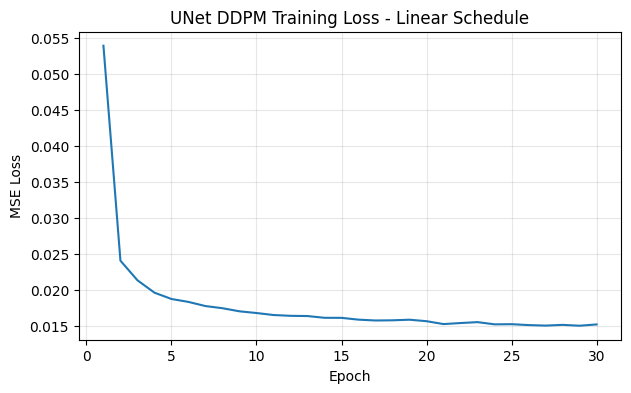

In [ ]:
# TODO: Train your UNet DDPM for 30 epochs on MNIST
# Loss: MSE between true noise eps and predicted noise eps_theta(x_t, t)
# Use Adam lr=1e-3, batch_size=128.
# Save checkpoints at epochs 5, 10, 20, 30.
# Plot training loss curve.

import torch.nn.functional as F

class TimeEmbedding(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half = 128 // 2
        freq = torch.exp(
            -torch.arange(half, device=t.device) * (8.0 / half)
        )
        args = t[:, None].float() * freq[None]
        embedding = torch.cat(
            [torch.cos(args), torch.sin(args)], dim=-1
        )
        return self.mlp(embedding)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=128):
        super().__init__()

        self.norm1 = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)

        h = h + self.time_proj(t_emb)[:, :, None, None]

        h = F.silu(self.norm2(h))
        h = self.conv2(h)

        return h + self.skip(x)


class SimpleUNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()

        self.time_embed = TimeEmbedding(time_dim)

        # Encoder: 1 → 32 → 64 → 128
        self.down1 = ResBlock(1, 32, time_dim)
        self.down2 = ResBlock(32, 64, time_dim)
        self.down3 = ResBlock(64, 128, time_dim)

        # Bottleneck
        self.bottleneck = ResBlock(128, 128, time_dim)

        # Decoder
        self.up1 = ResBlock(128 + 128, 128, time_dim)
        self.up2 = ResBlock(128 + 64, 64, time_dim)
        self.up3 = ResBlock(64 + 32, 32, time_dim)

        # Predict one-channel noise
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encoder
        x1 = self.down1(x, t_emb)
        x2 = self.down2(F.max_pool2d(x1, 2), t_emb)
        x3 = self.down3(F.max_pool2d(x2, 2), t_emb)

        # Bottleneck
        x = self.bottleneck(F.max_pool2d(x3, 2), t_emb)

        # Decoder + skip connections
        x = F.interpolate(x, size=x3.shape[-2:], mode="nearest")
        x = self.up1(torch.cat([x, x3], dim=1), t_emb)

        x = F.interpolate(x, size=x2.shape[-2:], mode="nearest")
        x = self.up2(torch.cat([x, x2], dim=1), t_emb)

        x = F.interpolate(x, size=x1.shape[-2:], mode="nearest")
        x = self.up3(torch.cat([x, x1], dim=1), t_emb)

        return self.final(x)


def train(model, schedule, loader, epochs=30, device=DEVICE,
          schedule_name="Linear", ckpt_epochs=(5, 10, 20, 30)):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    losses = []
    checkpoints = {}

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for x0, _ in loader:
            x0 = x0.to(device)

            # Random timestep for each image
            t = torch.randint(0, schedule.T, (x0.shape[0],), device=device)

            # Add noise according to the schedule
            x_t, noise = schedule.q_sample(x0, t)

            # Predict the noise
            pred_noise = model(x_t, t)

            # Compare predicted noise with true noise
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        print(f"Epoch {epoch:2d}/{epochs} | Loss: {avg_loss:.4f}")

        # Save model at the requested epochs
        if epoch in ckpt_epochs:
            checkpoints[epoch] = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    # Plot training loss
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, epochs + 1), losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"UNet DDPM Training Loss - {schedule_name} Schedule")
    plt.grid(alpha=0.3)
    plt.show()

    return losses, checkpoints


# Create the MNIST loader
loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

# Create model and linear noise schedule
model = SimpleUNet().to(DEVICE)

schedule = NoiseSchedule(
    T=1000,
    schedule="linear",
    device=DEVICE
)

# Train the model and save checkpoints at 5, 10, 20, 30
linear_losses, linear_checkpoints = train(
    model,
    schedule,
    loader,
    epochs=30,
    device=DEVICE,
    schedule_name="Linear"
)

Epoch  1/30 | Loss: 0.0839
Epoch  2/30 | Loss: 0.0421
Epoch  3/30 | Loss: 0.0362
Epoch  4/30 | Loss: 0.0337
Epoch  5/30 | Loss: 0.0323
Epoch  6/30 | Loss: 0.0314
Epoch  7/30 | Loss: 0.0310
Epoch  8/30 | Loss: 0.0302
Epoch  9/30 | Loss: 0.0300
Epoch 10/30 | Loss: 0.0298
Epoch 11/30 | Loss: 0.0293
Epoch 12/30 | Loss: 0.0291
Epoch 13/30 | Loss: 0.0290
Epoch 14/30 | Loss: 0.0287
Epoch 15/30 | Loss: 0.0283
Epoch 16/30 | Loss: 0.0283
Epoch 17/30 | Loss: 0.0279
Epoch 18/30 | Loss: 0.0280
Epoch 19/30 | Loss: 0.0280
Epoch 20/30 | Loss: 0.0277
Epoch 21/30 | Loss: 0.0275
Epoch 22/30 | Loss: 0.0275
Epoch 23/30 | Loss: 0.0274
Epoch 24/30 | Loss: 0.0274
Epoch 25/30 | Loss: 0.0272
Epoch 26/30 | Loss: 0.0273
Epoch 27/30 | Loss: 0.0271
Epoch 28/30 | Loss: 0.0272
Epoch 29/30 | Loss: 0.0269
Epoch 30/30 | Loss: 0.0271


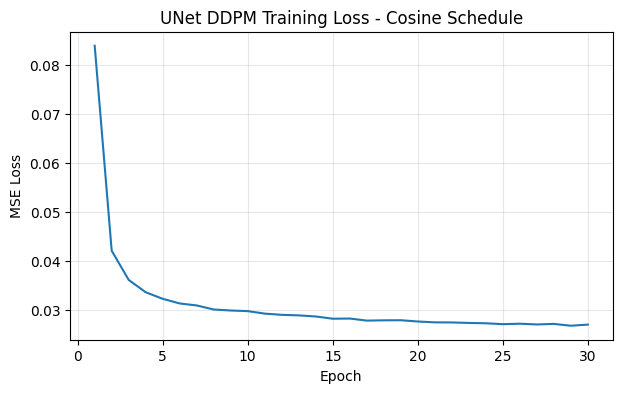

In [ ]:
# Create model and cosine noise schedule
cosine_model = SimpleUNet().to(DEVICE)

cosine_schedule = NoiseSchedule(
    T=1000,
    schedule="cosine",
    device=DEVICE
)

# Train for 30 epochs and save checkpoints at 5, 10, 20, 30
cosine_losses, cosine_checkpoints = train(
    cosine_model,
    cosine_schedule,
    loader,
    epochs=30,
    device=DEVICE,
    schedule_name="Cosine"
)


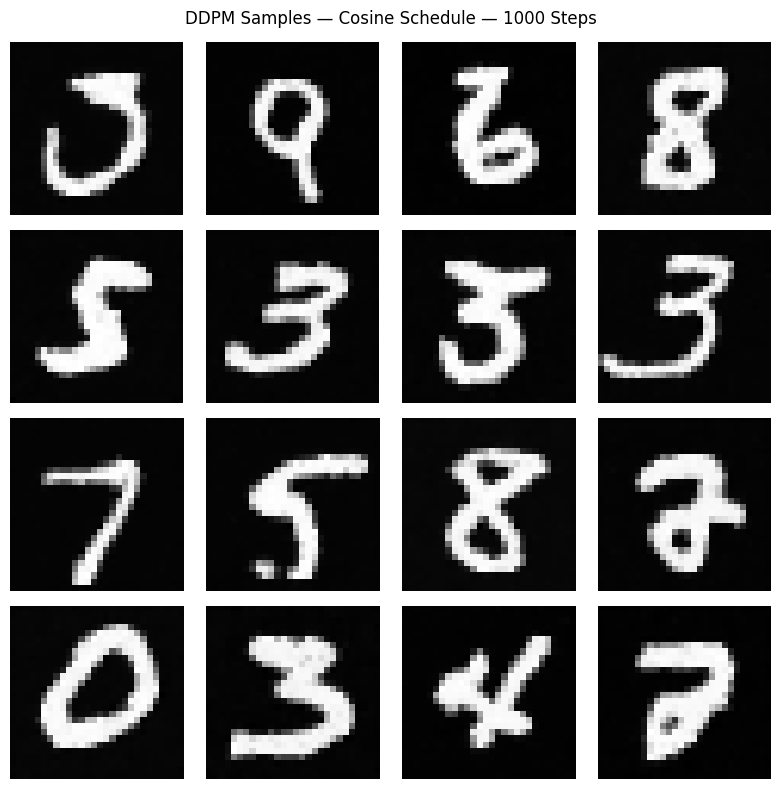

In [ ]:
# DDPM sampling (1000 steps — slow)
# Cosine schedule, 16 MNIST samples

@torch.no_grad()
def ddpm_sample(cosine_model, betas, T, x_initial):
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0).to(DEVICE)

    x = x_initial  # Start from pure noise

    for t in reversed(range(T)):
        t_tensor = torch.tensor([t] * x.shape[0], device=DEVICE)

        # Model predicts the noise currently present in x
        eps_pred = cosine_model(x, t_tensor)

        alpha_bar_t = alpha_bars[t]
        alpha_bar_prev = (
            alpha_bars[t - 1]
            if t > 0
            else torch.tensor(1.0, device=DEVICE)
        )

        # posterior mean
        coef1 = betas[t] / (1 - alpha_bar_t).sqrt()

        x = (1 / alphas[t].sqrt()) * (
            x - coef1 * eps_pred
        )

        if t > 0:
            noise_for_step = torch.randn_like(x)

            # Use the instructor's sampling equation
            x = x + betas[t].sqrt() * noise_for_step

    return x

# Generate 16 samples from the cosine schedule

T = 1000
n_samples = 16

# Start with pure random noise
x_initial = torch.randn(
    n_samples, 1, 28, 28,
    device=DEVICE
)

# Sample using the COSINE schedule
samples = ddpm_sample(
    cosine_model,
    cosine.betas,
    T,
    x_initial
)

# Display samples in a 4x4 grid

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        samples[i, 0].detach().cpu(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("DDPM Samples — Cosine Schedule — 1000 Steps")
plt.tight_layout()
plt.show()


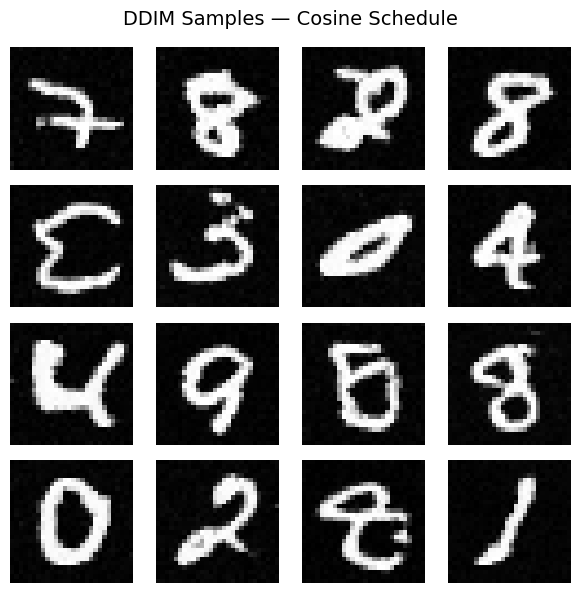

In [ ]:
#DDIM 50 deterministic steps

@torch.no_grad()
def ddim_sample(
    cosine_model,
    schedule,
    n_steps=50,
    eta=0.0,
    batch_size=16,
    device=DEVICE
):
    """
    DDIM sampler for the epsilon-prediction UNet trained above.

    Returns:
        x: Tensor of shape [batch_size, 1, 28, 28] in [0, 1]
    """

    cosine_model.eval()

    # ---------------------------------------------------------
    # Select timesteps from T-1 down to 0.
    # Use linspace, then remove duplicates in case n_steps
    # does not divide T-1 exactly.
    # ---------------------------------------------------------
    timesteps = torch.linspace(
        schedule.T - 1,
        0,
        n_steps,
        device=device
    ).round().long()

    timesteps = torch.unique_consecutive(timesteps)

    # Start from pure Gaussian noise.
    x = torch.randn(
        batch_size, 1, 28, 28,
        device=device
    )

    # ---------------------------------------------------------
    # DDIM reverse process
    # ---------------------------------------------------------
    for i in range(len(timesteps) - 1):

        t = timesteps[i]
        t_next = timesteps[i + 1]

        # Broadcast scalar schedule values across the batch/image.
        alpha_bar_t = schedule.alphas_cumprod[t]
        alpha_bar_next = schedule.alphas_cumprod[t_next]

        # Timestep tensor expected by SimpleUNet:
        # shape = [batch_size]
        t_batch = torch.full(
            (batch_size,),
            t,
            device=device,
            dtype=torch.long
        )

        # Predict epsilon_theta(x_t, t)
        pred_noise = cosine_model(x, t_batch)

        # -----------------------------------------------------
        # Predict x_0 from x_t and predicted noise:
        #
        # x0 = (x_t - sqrt(1-a_t) * eps) / sqrt(a_t)
        # -----------------------------------------------------
        x0_pred = (
            x - torch.sqrt(1.0 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        # Training images are in [0, 1].
        x0_pred = torch.clamp(x0_pred, 0.0, 1.0)

        # -----------------------------------------------------
        # DDIM sigma.
        #
        # sigma_t =
        # eta * sqrt((1-a_next)/(1-a_t))
        #        * sqrt(1-a_t/a_next)
        # -----------------------------------------------------
        sigma = (
            eta
            * torch.sqrt(
                (1.0 - alpha_bar_next)
                / (1.0 - alpha_bar_t)
            )
            * torch.sqrt(
                1.0 - alpha_bar_t / alpha_bar_next
            )
        )

        # -----------------------------------------------------
        # Direction pointing toward x_t from x_0.
        # -----------------------------------------------------
        direction = torch.sqrt(
            torch.clamp(
                1.0 - alpha_bar_next - sigma**2,
                min=0.0
            )
        ) * pred_noise

        # -----------------------------------------------------
        # DDIM update:
        #
        # x_{t-1} =
        # sqrt(a_next) * x0
        # + direction
        # + sigma * z
        # -----------------------------------------------------
        if eta > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            torch.sqrt(alpha_bar_next) * x0_pred
            + direction
            + sigma * noise
        )

    # Final output is an image in [0, 1].
    return torch.clamp(x, 0.0, 1.0)


# =============================================================
# Generate 16 MNIST samples
# =============================================================

samples = ddim_sample(
    cosine_model=cosine_model,
    schedule=cosine_schedule,
    n_steps=50,
    eta=0.0,
    batch_size=16,
    device=DEVICE
)


# =============================================================
# Display as a 4x4 grid
# =============================================================

fig, axes = plt.subplots(
    4, 4,
    figsize=(6, 6)
)

for i, ax in enumerate(axes.flat):
    ax.imshow(
        samples[i, 0].detach().cpu(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    ax.axis("off")

plt.suptitle(
    "DDIM Samples — Cosine Schedule",
    fontsize=14
)
plt.tight_layout()
plt.show()



DDPM vs DDIM Sampling Time
DDPM  (1000 steps): 3.7257 s
DDIM  (  50 steps): 0.1920 s
DDIM  (  20 steps): 0.0736 s
DDIM  (   5 steps): 0.0159 s


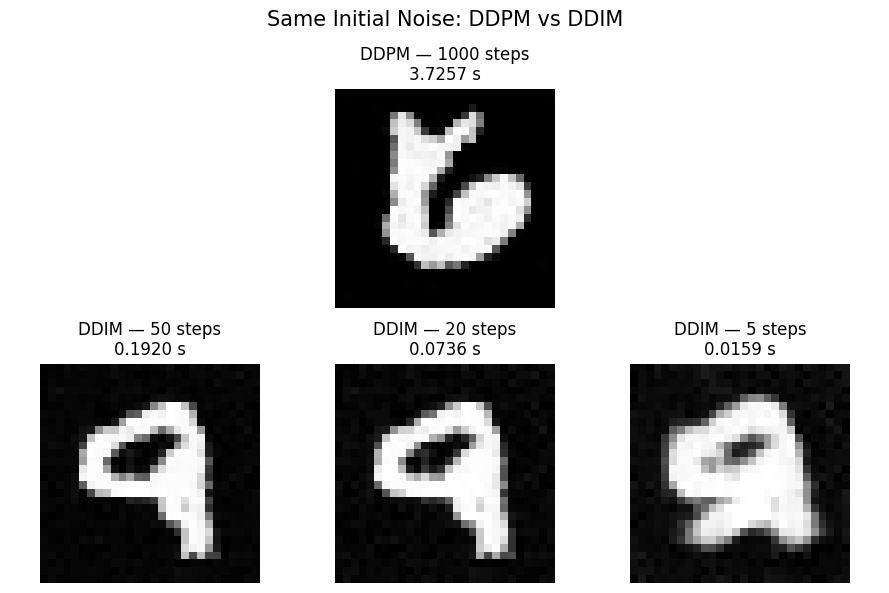

In [ ]:
# DDPM vs DDIM SAMPLING EXPERIMENT
#
# Generates ONE image with each:
#   1. DDPM  - 1000 steps
#   2. DDIM  - 50 steps
#   3. DDIM  - 20 steps
#   4. DDIM  - 5 steps


import time
import torch
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Make sure model is in evaluation mode
# ------------------------------------------------------------

cosine_model.eval()


# ============================================================
# DDPM SAMPLER
# ============================================================

@torch.no_grad()
def run_ddpm(model, betas, T, x_initial):

    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    x = x_initial.clone()

    for t in reversed(range(T)):

        t_tensor = torch.full(
            (x.shape[0],),
            t,
            device=x.device,
            dtype=torch.long
        )

        eps_pred = model(x, t_tensor)

        alpha_bar_t = alpha_bars[t]

        # Instructor's sampling equation
        coef1 = betas[t] / torch.sqrt(1.0 - alpha_bar_t)

        x = (1.0 / torch.sqrt(alphas[t])) * (
            x - coef1 * eps_pred
        )

        if t > 0:
            noise_for_step = torch.randn_like(x)
            x = x + torch.sqrt(betas[t]) * noise_for_step

    return x


# DDIM SAMPLER

@torch.no_grad()
def run_ddim(
    model,
    schedule,
    x_initial,
    n_steps,
    eta=0.0
):

    model.eval()

    device = x_initial.device
    batch_size = x_initial.shape[0]

    # Select evenly spaced timestamps T-1 -> 0
    timesteps = torch.linspace(
        schedule.T - 1,
        0,
        n_steps,
        device=device
    ).round().long()

    timesteps = torch.unique_consecutive(timesteps)

    x = x_initial.clone()

    for i in range(len(timesteps) - 1):

        t = timesteps[i]
        t_next = timesteps[i + 1]

        alpha_bar_t = schedule.alphas_cumprod[t]
        alpha_bar_next = schedule.alphas_cumprod[t_next]

        t_batch = torch.full(
            (batch_size,),
            t,
            device=device,
            dtype=torch.long
        )

        # Predict epsilon
        pred_noise = model(x, t_batch)

        # Predict x0
        x0_pred = (
            x
            - torch.sqrt(1.0 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        # MNIST was trained in [0, 1]
        x0_pred = torch.clamp(
            x0_pred,
            0.0,
            1.0
        )

        # DDIM sigma
        sigma = (
            eta
            * torch.sqrt(
                (1.0 - alpha_bar_next)
                / (1.0 - alpha_bar_t)
            )
            * torch.sqrt(
                1.0 - alpha_bar_t / alpha_bar_next
            )
        )

        # Direction toward x_t
        direction = torch.sqrt(
            torch.clamp(
                1.0 - alpha_bar_next - sigma**2,
                min=0.0
            )
        ) * pred_noise

        # eta=0 -> deterministic
        if eta == 0.0:
            noise = torch.zeros_like(x)
        else:
            noise = torch.randn_like(x)

        x = (
            torch.sqrt(alpha_bar_next) * x0_pred
            + direction
            + sigma * noise
        )

    return torch.clamp(x, 0.0, 1.0)


# COMMON STARTING NOISE

x_initial = torch.randn(
    1, 1, 28, 28,
    device=DEVICE
)


# Run DDPM

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

ddpm_result = run_ddpm(
    cosine_model,
    cosine_schedule.betas,
    cosine_schedule.T,
    x_initial
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

ddpm_time = time.perf_counter() - start


# Run DDIM — 50 steps

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

ddim50_result = run_ddim(
    cosine_model,
    cosine_schedule,
    x_initial,
    n_steps=50,
    eta=0.0
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

ddim50_time = time.perf_counter() - start

# Run DDIM — 20 steps

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

ddim20_result = run_ddim(
    cosine_model,
    cosine_schedule,
    x_initial,
    n_steps=20,
    eta=0.0
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

ddim20_time = time.perf_counter() - start

# Run DDIM — 15 steps

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

ddim20_result = run_ddim(
    cosine_model,
    cosine_schedule,
    x_initial,
    n_steps=15,
    eta=0.0
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

ddim20_time = time.perf_counter() - start


# Run DDIM — 5 steps

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()

ddim5_result = run_ddim(
    cosine_model,
    cosine_schedule,
    x_initial,
    n_steps=5,
    eta=0.0
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

ddim5_time = time.perf_counter() - start


# Print timing results

print()
print("=" * 60)
print("DDPM vs DDIM Sampling Time")
print("=" * 60)
print(f"DDPM  (1000 steps): {ddpm_time:.4f} s")
print(f"DDIM  (  50 steps): {ddim50_time:.4f} s")
print(f"DDIM  (  20 steps): {ddim20_time:.4f} s")
print(f"DDIM  (   5 steps): {ddim5_time:.4f} s")
print("=" * 60)


# Plot the four generated images
#
# Row 1: DDPM
# Row 2: DDIM 50 / 20 / 5

results = [
    (
        ddpm_result,
        f"DDPM — 1000 steps\n{ddpm_time:.4f} s"
    ),
    (
        ddim50_result,
        f"DDIM — 50 steps\n{ddim50_time:.4f} s"
    ),
    (
        ddim20_result,
        f"DDIM — 20 steps\n{ddim20_time:.4f} s"
    ),
    (
        ddim5_result,
        f"DDIM — 5 steps\n{ddim5_time:.4f} s"
    )
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(9, 6)
)

# Top row: DDPM in center
axes[0, 0].axis("off")

axes[0, 1].imshow(
    results[0][0][0, 0].detach().cpu(),
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[0, 1].set_title(results[0][1])
axes[0, 1].axis("off")

axes[0, 2].axis("off")


# Bottom row: DDIM 50 / 20 / 5
for ax, (result, title) in zip(
    axes[1],
    results[1:]
):
    ax.imshow(
        result[0, 0].detach().cpu(),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    ax.set_title(title)
    ax.axis("off")


plt.suptitle(
    "Same Initial Noise: DDPM vs DDIM",
    fontsize=15
)

plt.tight_layout()
plt.show()


Quality is visible degraded at 5 steps; I would need a minimum viable steps of 20 for DDIM for the use case of producing human-readable digits.

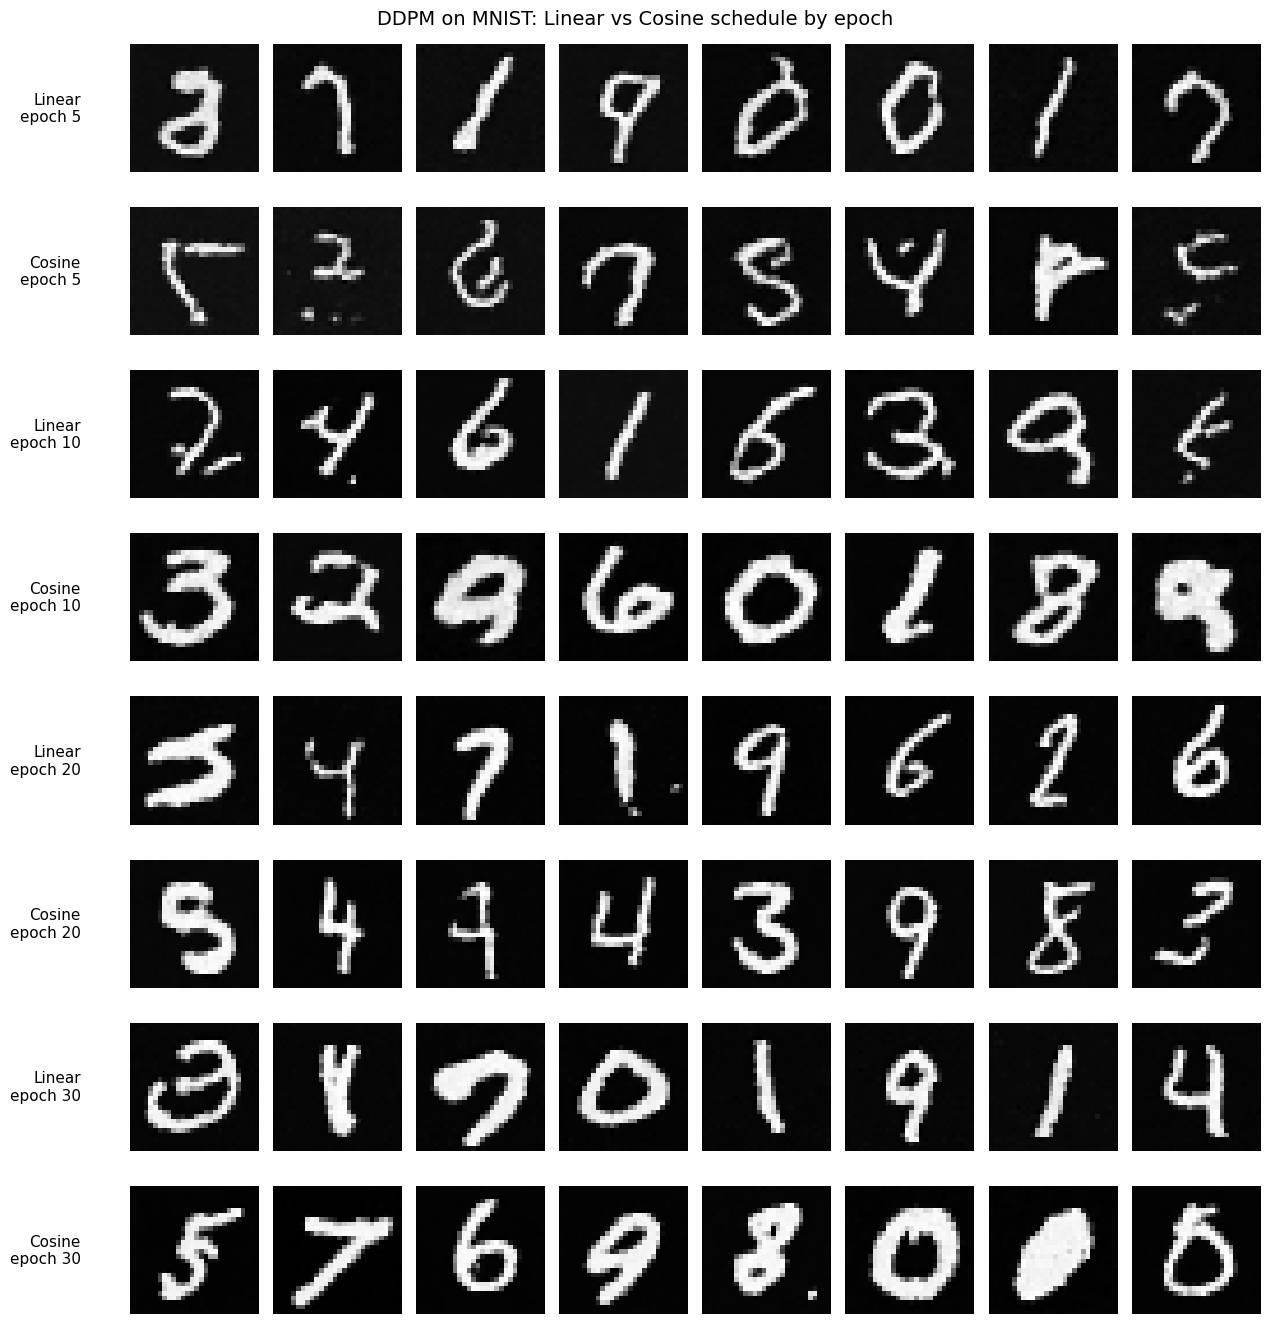

In [ ]:
# Linear vs Cosine DDPM comparison at epochs 5, 10, 20, 30
import copy

@torch.no_grad()
def compare_schedules(base_model, checkpoints, schedules,
                      epochs=(5, 10, 20, 30), n=8, seed=0):
    names = ["Linear", "Cosine"]

    # Same starting noise for every row in a given column
    torch.manual_seed(seed)
    noises = torch.randn(n, 1, 28, 28).to(DEVICE)

    # Work on a copy so the trained models in memory aren't overwritten
    net = copy.deepcopy(base_model).to(DEVICE)

    rows = len(epochs) * 2
    fig, axes = plt.subplots(rows, n, figsize=(1.6 * n, 1.7 * rows))

    for i, ep in enumerate(epochs):
        for k in range(2):  # 0 = linear, 1 = cosine
            r = 2 * i + k
            net.load_state_dict(checkpoints[k][ep])
            net.eval()

            for col in range(n):
                img = ddpm_sample(net, schedules[k].betas, schedules[k].T,
                                  x_initial=noises[col:col+1].clone())
                ax = axes[r, col]
                ax.imshow(img.squeeze().cpu(), cmap="gray")
                # Hide ticks/spines but keep the axis so the row label shows
                ax.set_xticks([]); ax.set_yticks([])
                for s in ax.spines.values():
                    s.set_visible(False)

            axes[r, 0].set_ylabel(f"{names[k]}\nepoch {ep}", rotation=0,
                                  fontsize=11, labelpad=35, ha="right", va="center")

    fig.suptitle("DDPM on MNIST: Linear vs Cosine schedule by epoch", fontsize=14)
    plt.tight_layout()
    plt.savefig("schedule_comparison_epochs.png", dpi=150, bbox_inches="tight")
    plt.show()


checkpoints = [linear_checkpoints, cosine_checkpoints]
schedules = [schedule, cosine_schedule]

compare_schedules(model, checkpoints, schedules)

### ❓ Reflect
1. Did cosine schedule produce better results than linear at 20 epochs? What visual difference did you see?
2. How much faster was DDIM vs DDPM? Was the quality difference acceptable for your use case?
3. Why does DDIM produce the same output every run given the same starting noise?

1. The cosine schedule appeared to produce higher-quality images at 20 epochs. I saw superior results for cosine as early as 10-epochs in, specifically in terms of digit completeness.
2. DDIM 50 was much faster than DDPM 1000 -about 20x (i.e. .192s vs 3.97s) with comparable image quality that was acceptable for my use case of simple digit generation.
3. Because DDIM is deterministic.

In [ ]:
!pip install torchmetrics torch-fidelity --quiet

In [ ]:
# FID comparison: Linear/Cosine × DDPM-1000/DDIM-50
from torchmetrics.image.fid import FrechetInceptionDistance
import pandas as pd

N_FID   = 2000     # use 10_000 for final numbers
FEATURE = 2048     # standard Inception features
BATCH   = 500
SEED    = 0

# Data is in [0, 1] (ToTensor only), so clamp + scale is correct
def prepare_for_fid(images):
    images = images.clamp(0, 1).repeat(1, 3, 1, 1)
    return (images * 255).round().to(torch.uint8)

@torch.no_grad()
def generate_samples(model, schedule, method, n=N_FID, batch=BATCH, seed=SEED):
    model.eval()
    torch.manual_seed(seed)                    # same noise stream per method
    out, done = [], 0
    while done < n:
        b = min(batch, n - done)
        if method == "ddpm":
            noise = torch.randn(b, 1, 28, 28, device=DEVICE)
            img = ddpm_sample(model, schedule.betas, schedule.T, noise)
        elif method == "ddim":
            img = ddim_sample(model, schedule, n_steps=50, eta=0.0,
                              batch_size=b, device=DEVICE)
        out.append(img.cpu())
        done += b
        print(f"  {method}: {done}/{n}")
    return torch.cat(out)

# Real images: N random training images, statistics computed once
g = torch.Generator().manual_seed(SEED)
idx = torch.randperm(len(dataset), generator=g)[:N_FID]
real_images = prepare_for_fid(torch.stack([dataset[i][0] for i in idx]))

fid = FrechetInceptionDistance(feature=FEATURE, reset_real_features=False).to(DEVICE)
for b in real_images.split(250):
    fid.update(b.to(DEVICE), real=True)

configs = [
    ("Linear DDPM-1000", model,        schedule,        "ddpm"),
    ("Cosine DDPM-1000", cosine_model, cosine_schedule, "ddpm"),
    ("Linear DDIM-50",   model,        schedule,        "ddim"),
    ("Cosine DDIM-50",   cosine_model, cosine_schedule, "ddim"),
]

results = {}
for name, m, s, method in configs:
    print(f"Generating {name} ...")
    generated = prepare_for_fid(generate_samples(m, s, method))
    fid.reset()                                # clears generated stats, keeps real
    for b in generated.split(250):
        fid.update(b.to(DEVICE), real=False)
    results[name] = fid.compute().item()

fid_table = pd.DataFrame({"Method": list(results), "FID": list(results.values())})
display(fid_table.round(2))

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 90.0MB/s]


Generating Linear DDPM-1000 ...
  ddpm: 500/2000
  ddpm: 1000/2000
  ddpm: 1500/2000
  ddpm: 2000/2000
Generating Cosine DDPM-1000 ...
  ddpm: 500/2000
  ddpm: 1000/2000
  ddpm: 1500/2000
  ddpm: 2000/2000
Generating Linear DDIM-50 ...
  ddim: 500/2000
  ddim: 1000/2000
  ddim: 1500/2000
  ddim: 2000/2000
Generating Cosine DDIM-50 ...
  ddim: 500/2000
  ddim: 1000/2000
  ddim: 1500/2000
  ddim: 2000/2000


,Method,FID
0,Linear DDPM-1000,22.34
1,Cosine DDPM-1000,18.87
2,Linear DDIM-50,60.61
3,Cosine DDIM-50,47.61


1. We recommend DDIM-20 based on a wall-clock time for image generation of .08s that lies comfortably within the sub-200ms latency constraint for a real-time creative tool, while producing outputs of similar quality as DDPM (1000 steps). As a caveat, this recommendation applies to simple image-generation applications, as the aforementioned .08s image-generation time was for grayscale 28x28 hand-written digits and not photo-realistic images.

- DDPM would produce highest-quality images; however, it requires many sequential denoising time-steps (e.g., 1,000), which is too slow for real-time image generation applications.

- DDIM does not require sequential steps, sampling time-steps at for example 50 evenly spaced points while still producing essentially DDPM-quality samples at a fraction (~5%) of DDPM's compute and time costs.

- While we recommend DDIM, we do however suggest a lower step count of 20 as opposed to 50 to meet the sub-200ms application latency constraint; although we managed to clock DDIM-50 at .192s, some sacrifice of image quality may be required to meet the primary project constraint of sub-200ms latency for real-time applications.

2. A lower FID score does not mean a cosine noise schedule is always better; it means such a schedule was preferable for the specific setup and image type in question, e.g., small images. A linear schedule could even outperform a cosine schedule on larger images, which may require more aggressive noising to shift more of the model's training from minimally noised and hence easy examples to the more instructive middle stages of more heavily noised images.

3. If I removed the skip connections from my UNet, I would expect image quality to degrade dramatically. As the encoder compresses the input to progressively smaller sizes until it reaches a 3×3 "bottleneck," it produces feature maps containing important details at each resolution, which the skip connections carry forward. The decoder then progressively enlarges this highly compressed representation, while the skip connections in turn supply the fine spatial details previously captured at each corresponding resolution. Without skip connections, generated images may be generally accurate and thus recognizable yet lack sufficient precision to communicate key details required to for example in the case of MNIST tell certain digits such as a 3 and 8 apart.

4. The reason a user may receive the same image after pressing "generate" is because DDIM with eta = 0 is deterministic. This means that no new noise is added at each stage of image generation, as eta = 0; accordingly, it is only the random number generator's seed, which is apparently unchanging in this example failure mode, that creates the same starting-point noise, repeatedly resulting in the same image. Two fixes that preserve latency are (1) ensuring the seed is different for each image generation attempt; and/or (2) slightly increasing eta, which would add a small amount of randomness at each denoising stage that would gradually "walk" the image to different possible outcomes (testing required to determine the optimal amount to preserve image quality).

---
## Submission
- [ ] Push to `genai-course/week2/lab2.ipynb`
- [ ] Loss curve plotted
- [ ] Schedule comparison visualised
- [ ] DDIM vs DDPM timing + quality comparison